# Post-2050 holdout evaluation and interpretation

This notebook evaluates post-2050 XGBoost predictions against true `TREFMXAV_U` values available in the holdout period, then interprets scenario, seasonal, spatial, and Manchester-focused patterns in light of that evaluation.

In [2]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent

else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/jacobwoodland/Semester 2/EART60702/Assignment 2/Project Folder/eds_project2


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from src.config import (
    TABLES_DIR,
    FIGURES_DIR,
    POST2050_HOLDOUT_PREDICTIONS,
    POST2050_METRICS_OVERALL,
    POST2050_METRICS_BY_SCENARIO,
    POST2050_METRICS_BY_SEASON,
    POST2050_METRICS_BY_SCENARIO_SEASON,
    POST2050_METRICS_BY_YEAR,
)
from src.evaluation import regression_metrics

In [4]:
post2050 = pd.read_csv(POST2050_HOLDOUT_PREDICTIONS)

# Convert longitudes to typical format rather than 0-360
post2050_plot = post2050.copy()
post2050_plot["lon_plot"] = ((post2050_plot["lon"] + 180) % 360) - 180

In [5]:
print("Columns:")
print(post2050_plot.columns.tolist())
print()

print("Shape:", post2050_plot.shape)
print("Year range:", post2050_plot["year"].min(), "to", post2050_plot["year"].max())
print()

required_cols = ["TREFMXAV_U_true", "pred_TREFMXAV_U", "error"]
missing = [col for col in required_cols if col not in post2050_plot.columns]
print("Missing required columns:", missing)

print()
print("Missing values:")
print(post2050_plot[["TREFMXAV_U_true", "pred_TREFMXAV_U", "error"]].isna().sum())

post2050_plot.head()

Columns:
['scenario', 'time', 'TREFMXAV_U_true', 'TREFHT', 'FLNS', 'FSNS', 'PRECT', 'PRSN', 'QBOT', 'UBOT', 'VBOT', 'lat', 'lon', 'year', 'month', 'monthly_sin', 'monthly_cos', 'wind_speed', 'TREFHT_lag1', 'PRECT_lag1', 'PRSN_lag1', 'FLNS_lag1', 'FSNS_lag1', 'QBOT_lag1', 'wind_speed_lag1', 'pred_TREFMXAV_U', 'season', 'decade', 'error', 'abs_error', 'squared_error', 'lon_plot']

Shape: (93744, 32)
Year range: 2050 to 2080

Missing required columns: []

Missing values:
TREFMXAV_U_true    0
pred_TREFMXAV_U    0
error              0
dtype: int64


,scenario,time,TREFMXAV_U_true,TREFHT,FLNS,FSNS,PRECT,PRSN,QBOT,UBOT,...,FSNS_lag1,QBOT_lag1,wind_speed_lag1,pred_TREFMXAV_U,season,decade,error,abs_error,squared_error,lon_plot
0,3,2050-01-01 00:00:00,285.80136,283.99677,37.516384,30.577051,2.521736e-06,1.648166e-14,0.006410,5.582342,...,34.724420,0.005628,2.141264,285.69520,DJF,2050,-0.106171,0.106171,0.011272,-1.25
1,3,2050-02-01 00:00:00,285.41544,282.44060,66.326950,79.958450,8.721353e-07,3.524978e-14,0.005101,-0.701649,...,30.577051,0.006410,7.836511,285.14316,DJF,2050,-0.272278,0.272278,0.074135,-1.25
2,3,2050-03-01 00:00:00,284.60860,281.54675,60.539158,117.381300,7.776718e-07,7.428997e-10,0.004784,-1.219418,...,79.958450,0.005101,2.899583,284.75696,MAM,2050,0.148346,0.148346,0.022007,-1.25
3,3,2050-04-01 00:00:00,289.54980,284.74783,59.838787,176.792770,9.672199e-07,2.614217e-14,0.005760,1.609725,...,117.381300,0.004784,1.402428,289.38780,MAM,2050,-0.162018,0.162018,0.026250,-1.25
4,3,2050-05-01 00:00:00,294.81363,288.92102,66.239780,248.411360,2.893328e-07,2.476724e-15,0.007576,-2.432174,...,176.792770,0.005760,1.632368,294.00480,MAM,2050,-0.808838,0.808838,0.654219,-1.25


In [6]:
# Define post2050 periods

period_labels = ["2050-2059", "2060-2069", "2070-2080"]

def assign_period(year):
    if pd.isna(year):
        return np.nan
    year = int(year)
    if 2050 <= year <= 2059:
        return "2050-2059"
    if 2060 <= year <= 2069:
        return "2060-2069"
    if 2070 <= year <= 2080:
        return "2070-2080"
    return np.nan

def add_period_column(df, year_col="year", period_col="period"):
    out = df.copy()
    out[period_col] = out[year_col].apply(assign_period)
    out[period_col] = pd.Categorical(out[period_col], categories=period_labels, ordered=True)
    return out

post2050 = add_period_column(post2050)
post2050_plot = add_period_column(post2050_plot)

print(post2050["period"].value_counts(dropna=False).sort_index())
print(post2050_plot["period"].value_counts(dropna=False).sort_index())

period
2050-2059    30240
2060-2069    30240
2070-2080    33264
Name: count, dtype: int64
period
2050-2059    30240
2060-2069    30240
2070-2080    33264
Name: count, dtype: int64


## Overall holdout evaluation

Before interpreting post-2050 patterns, first assess how closely the final model predictions match the true post-2050 `TREFMXAV_U` values

In [7]:
overall_metrics = pd.read_csv(POST2050_METRICS_OVERALL)
metrics_by_scenario = pd.read_csv(POST2050_METRICS_BY_SCENARIO)
metrics_by_season = pd.read_csv(POST2050_METRICS_BY_SEASON)
metrics_by_scenario_season = pd.read_csv(POST2050_METRICS_BY_SCENARIO_SEASON)
metrics_by_year = pd.read_csv(POST2050_METRICS_BY_YEAR)

overall_metrics

,n,rmse,mae,r2,bias
0,93744,0.413312,0.291305,0.992141,-0.113444


In [8]:
# Recomputation check
regression_metrics(post2050_plot["TREFMXAV_U_true"], post2050_plot["pred_TREFMXAV_U"])

{'rmse': 0.4133118888849451,
 'mae': 0.2913051731310804,
 'r2': 0.9921405818379767,
 'bias': -0.11344443559054454}

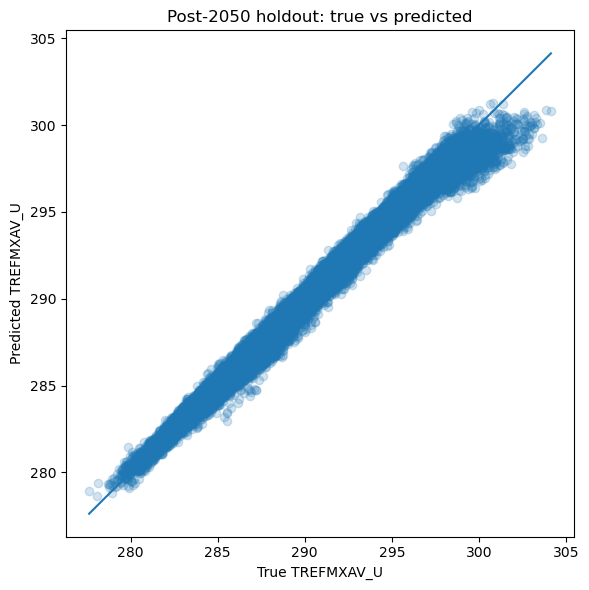

In [9]:
# True vs predicted

plt.figure(figsize=(6, 6))
plt.scatter(
    post2050_plot["TREFMXAV_U_true"],
    post2050_plot["pred_TREFMXAV_U"],
    alpha=0.2
)

min_val = min(post2050_plot["TREFMXAV_U_true"].min(), post2050_plot["pred_TREFMXAV_U"].min())
max_val = max(post2050_plot["TREFMXAV_U_true"].max(), post2050_plot["pred_TREFMXAV_U"].max())

plt.plot([min_val, max_val], [min_val, max_val])
plt.xlabel("True TREFMXAV_U")
plt.ylabel("Predicted TREFMXAV_U")
plt.title("Post-2050 holdout: true vs predicted")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "post2050_true_vs_predicted_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

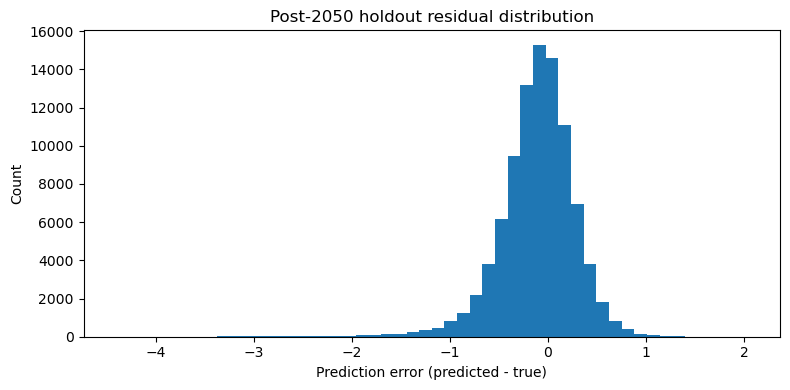

In [10]:
# Residuals

plt.figure(figsize=(8, 4))
plt.hist(post2050_plot["error"], bins=50)
plt.xlabel("Prediction error (predicted - true)")
plt.ylabel("Count")
plt.title("Post-2050 holdout residual distribution")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "post2050_residual_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
metrics_by_scenario.sort_values("scenario")

,scenario,n,rmse,mae,r2,bias
0,3,15624,0.435964,0.299824,0.991776,-0.126330
1,4,15624,0.404455,0.287617,0.992213,-0.117835
2,5,15624,0.380435,0.279892,0.993210,-0.083862
3,6,15624,0.447552,0.304765,0.990735,-0.123344
4,7,15624,0.406421,0.289428,0.992465,-0.110150
5,8,15624,0.401374,0.286304,0.992468,-0.119144


In [12]:
metrics_by_season.sort_values("season")

,season,n,rmse,mae,r2,bias
0,DJF,23436,0.291135,0.224158,0.960233,-0.082964
1,JJA,23436,0.541641,0.346909,0.948285,-0.142440
2,MAM,23436,0.416864,0.316442,0.980126,-0.111958
3,SON,23436,0.362487,0.277713,0.986957,-0.116417


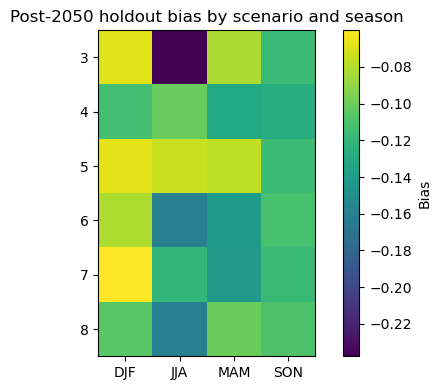

In [13]:
# Bias heatmap by scenario and season

bias_pivot = metrics_by_scenario_season.pivot(index="scenario", columns="season", values="bias")

plt.figure(figsize=(6, 4))
plt.imshow(bias_pivot)
plt.xticks(range(len(bias_pivot.columns)), bias_pivot.columns)
plt.yticks(range(len(bias_pivot.index)), bias_pivot.index)
plt.colorbar(label="Bias")
plt.title("Post-2050 holdout bias by scenario and season")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "post2050_bias_by_scenario_season.png", dpi=300, bbox_inches="tight")
plt.show()

## Annual post-2050 trajectories by scenario

First compare true and predicted annual mean `TREFMXAV_U` by scenario, then summarise the predicted pattern across scenarios

In [14]:
annual_preds = (
    post2050_plot
    .groupby(["scenario", "year"])[["TREFMXAV_U_true", "pred_TREFMXAV_U", "error"]]
    .mean()
    .reset_index()
)

annual_preds.head()

,scenario,year,TREFMXAV_U_true,pred_TREFMXAV_U,error
0,3,2050,288.756493,288.701367,-0.055126
1,3,2051,288.868533,288.900843,0.032310
2,3,2052,288.837021,288.868417,0.031396
3,3,2053,288.752871,288.693304,-0.059568
4,3,2054,288.821433,288.705980,-0.115453


In [15]:
# Check all scenarios and full period are there

annual_preds.groupby("scenario")[["year"]].agg(["min", "max", "count"])

year            
           min   max count
scenario                  
3         2050  2080    31
4         2050  2080    31
5         2050  2080    31
6         2050  2080    31
7         2050  2080    31
8         2050  2080    31

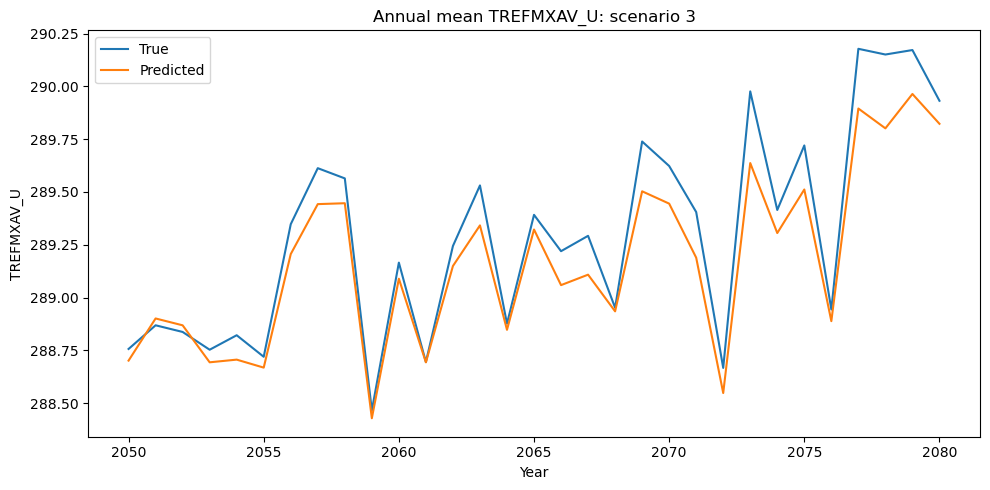

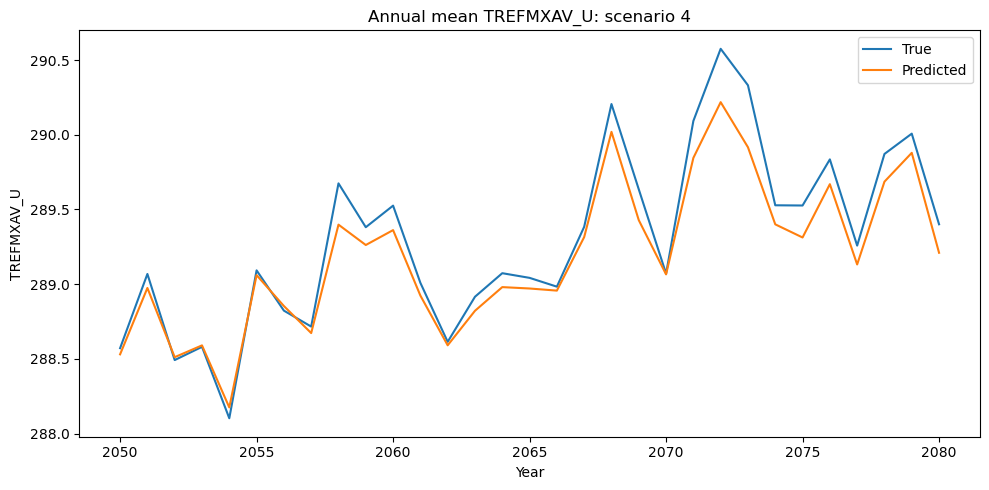

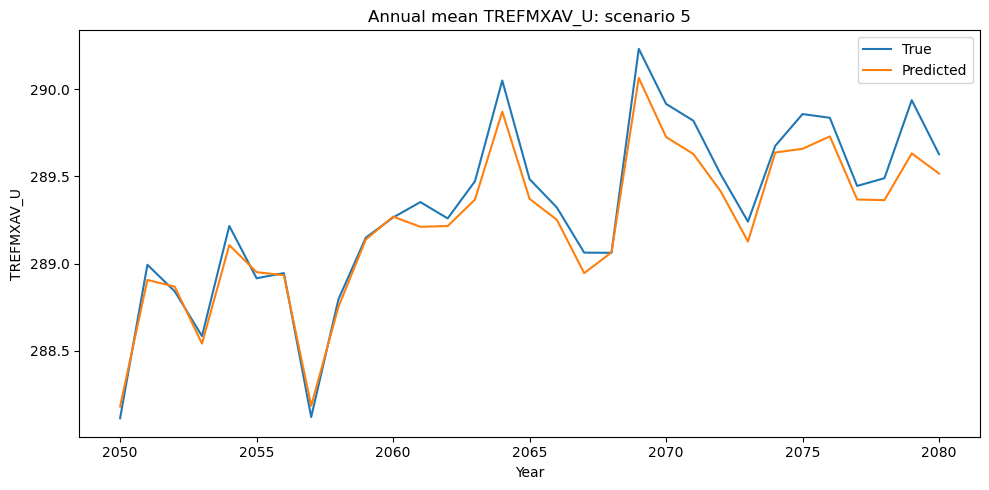

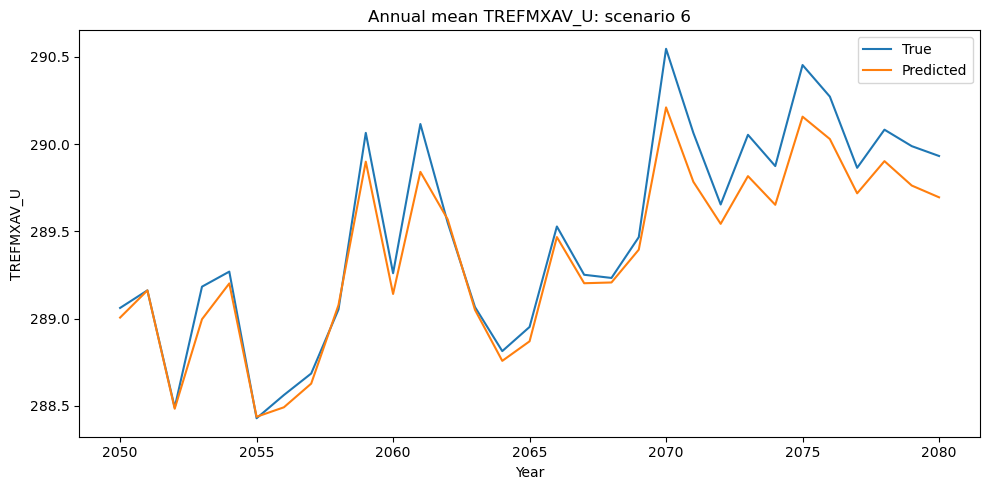

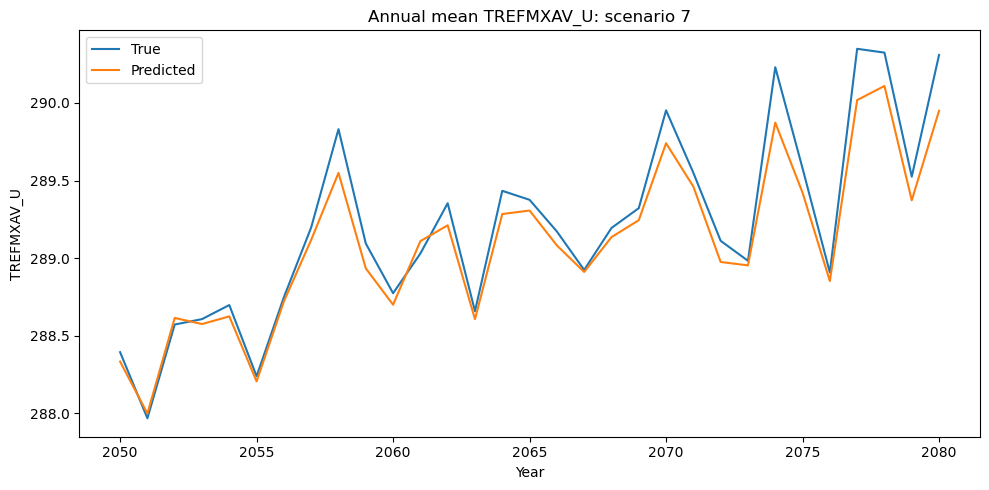

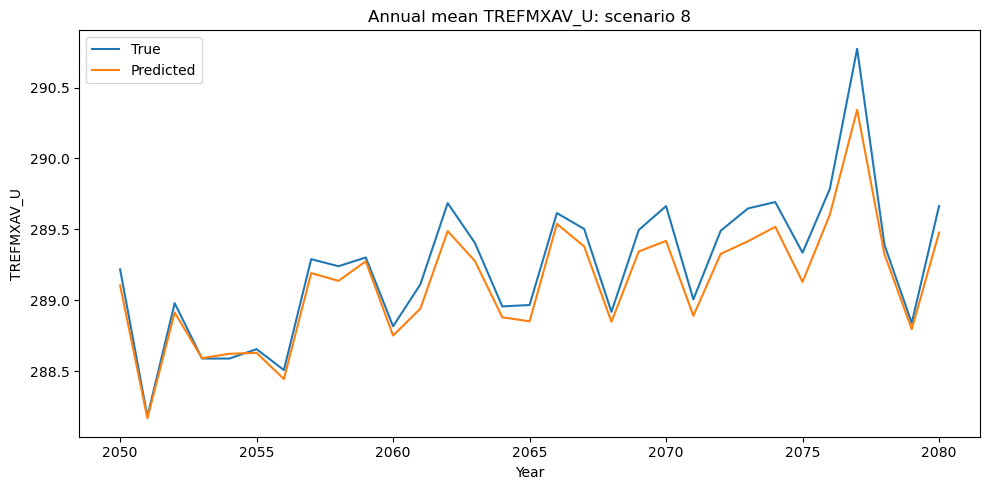

In [16]:
for scenario, grp in annual_preds.groupby("scenario"):
    plt.figure(figsize=(10, 5))
    plt.plot(grp["year"], grp["TREFMXAV_U_true"], label="True")
    plt.plot(grp["year"], grp["pred_TREFMXAV_U"], label="Predicted")
    plt.title(f"Annual mean TREFMXAV_U: scenario {scenario}")
    plt.xlabel("Year")
    plt.ylabel("TREFMXAV_U")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [17]:
annual_summary = (
    annual_preds
    .groupby("scenario")[["TREFMXAV_U_true", "pred_TREFMXAV_U", "error"]]
    .agg(["mean", "min", "max"])
)

annual_summary

TREFMXAV_U_true                         pred_TREFMXAV_U              \
                    mean         min         max            mean         min   
scenario                                                                       
3             289.291230  288.465577  290.177555      289.164900  288.428441   
4             289.302754  288.102867  290.574936      289.184918  288.175240   
5             289.309161  288.112276  290.232042      289.225299  288.179486   
6             289.483289  288.429655  290.545638      289.359944  288.438131   
7             289.206557  287.967901  290.348941      289.096407  287.998383   
8             289.235590  288.179872  290.773883      289.116446  288.167002   

                         error                      
                 max      mean       min       max  
scenario                                            
3         289.963739 -0.126330 -0.349555  0.032310  
4         290.217960 -0.117835 -0.414644  0.072373  
5         290.064985 -0.083862 -0.305365  0.067209  
6         290.210075 -0.123344 -0.335563  0.024878  
7         290.109453 -0.110150 -0.359602  0.079677  
8         290.343588 -0.119144 -0.430295  0.033583

In [18]:
annual_summary.to_csv(TABLES_DIR / "post2050_annual_true_vs_pred_summary_by_scenario.csv")

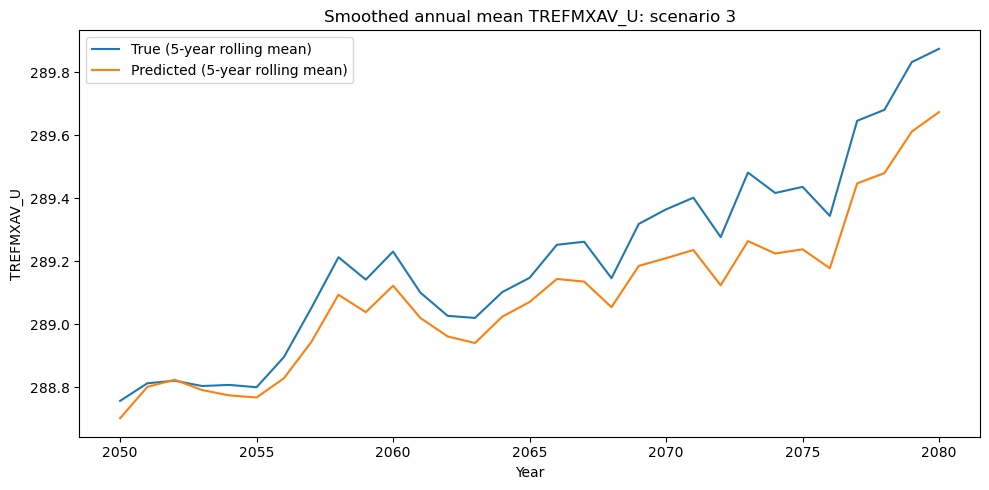

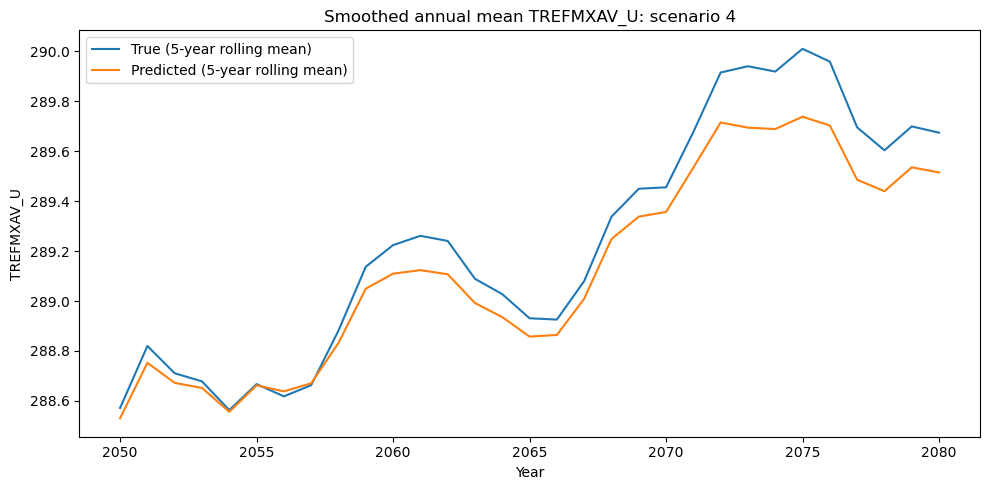

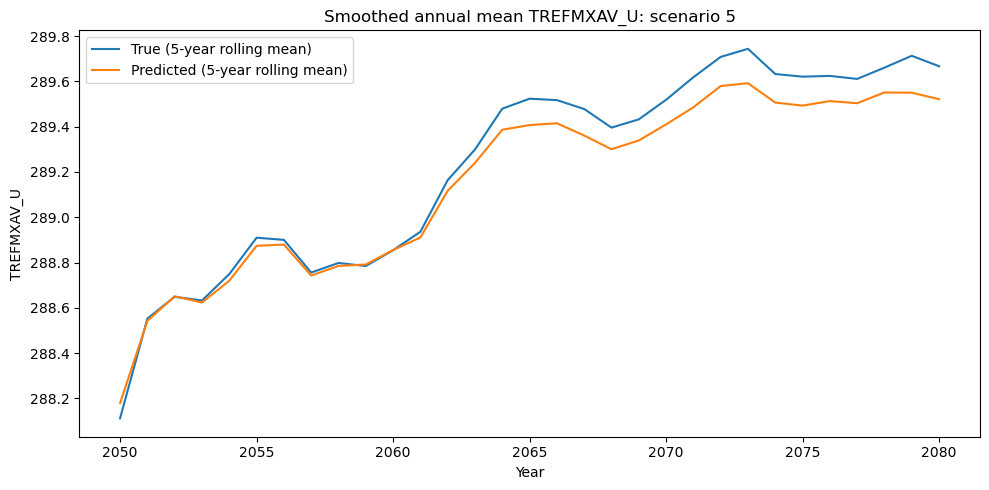

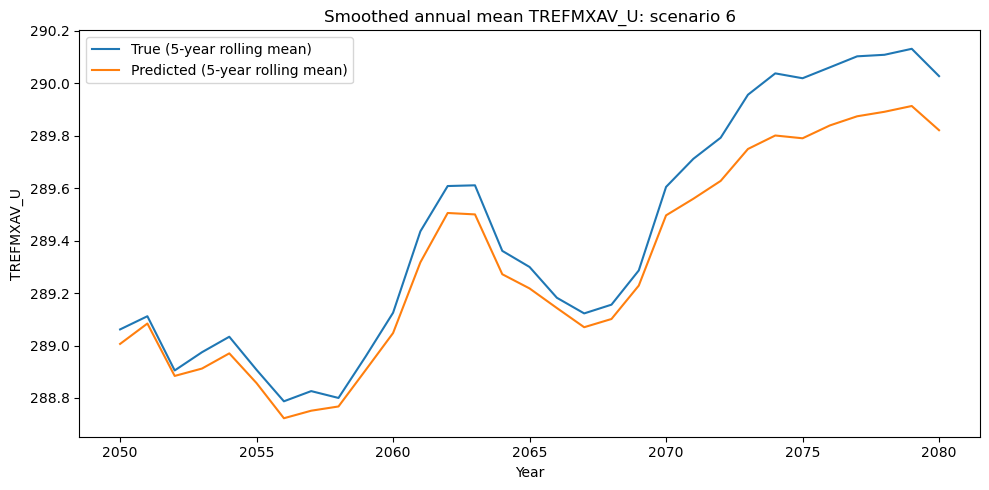

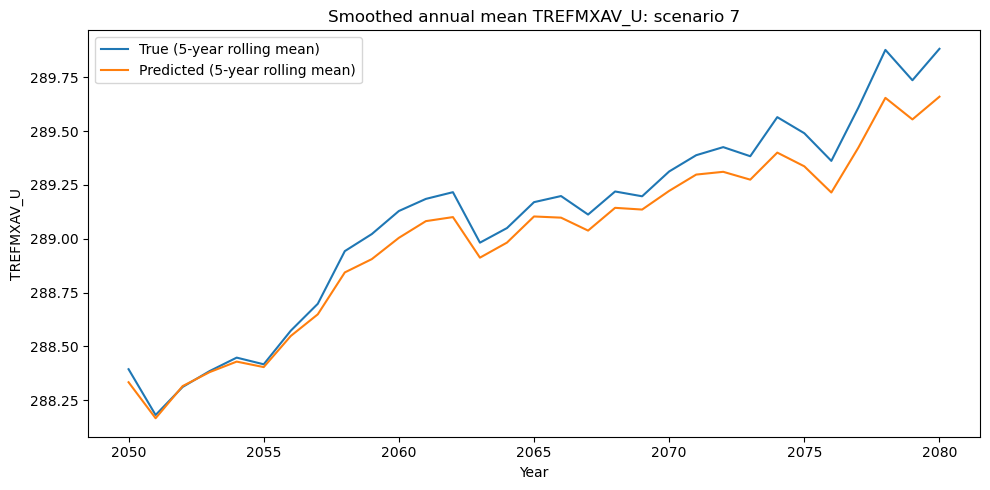

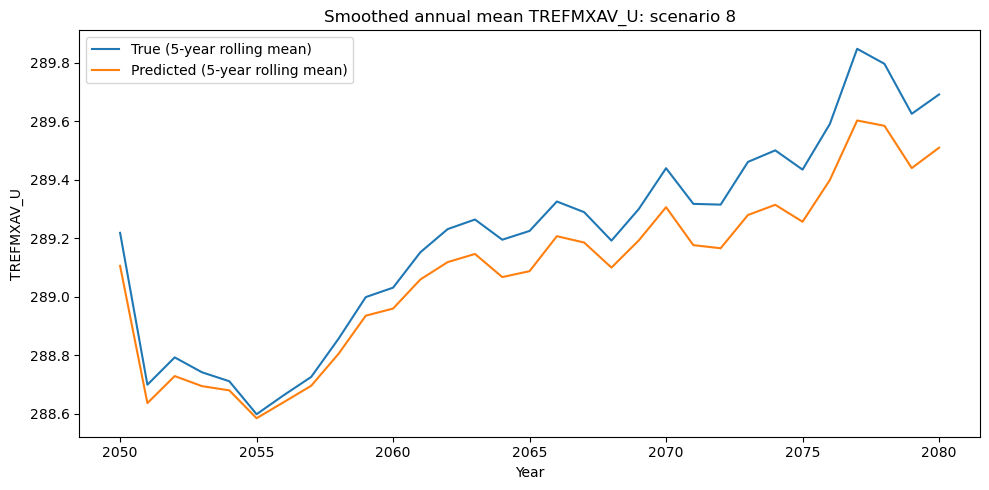

In [19]:
# Improve the plot by smoothing some of the noise using a 5-year rolling avergae

annual_preds = annual_preds.sort_values(["scenario", "year"]).copy()

annual_preds["true_roll5"] = (
    annual_preds.groupby("scenario")["TREFMXAV_U_true"]
    .transform(lambda s: s.rolling(5, min_periods=1).mean())
)

annual_preds["pred_roll5"] = (
    annual_preds.groupby("scenario")["pred_TREFMXAV_U"]
    .transform(lambda s: s.rolling(5, min_periods=1).mean())
)

for scenario, grp in annual_preds.groupby("scenario"):
    plt.figure(figsize=(10, 5))
    plt.plot(grp["year"], grp["true_roll5"], label="True (5-year rolling mean)")
    plt.plot(grp["year"], grp["pred_roll5"], label="Predicted (5-year rolling mean)")
    plt.title(f"Smoothed annual mean TREFMXAV_U: scenario {scenario}")
    plt.xlabel("Year")
    plt.ylabel("TREFMXAV_U")
    plt.legend()
    plt.tight_layout()
    plt.show()

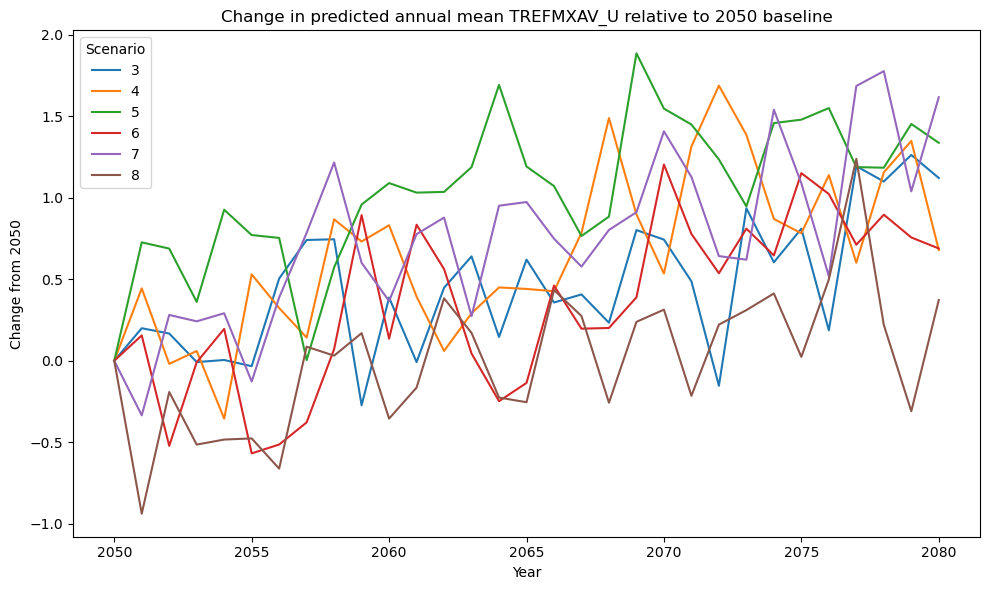

In [20]:
# PLot relative to 2050 baseline year

annual_change = annual_preds.copy()

baseline = (
    annual_change[annual_change["year"]==2050]
    .set_index("scenario")["pred_TREFMXAV_U"]
)

annual_change["baseline_2050"] = annual_change["scenario"].map(baseline)
annual_change["change_from_2050"] = annual_change["pred_TREFMXAV_U"] - annual_change["baseline_2050"]

plt.figure(figsize=(10, 6))

for scenario, grp in annual_change.groupby("scenario"):
    plt.plot(grp["year"], grp["change_from_2050"], label=scenario)

plt.title("Change in predicted annual mean TREFMXAV_U relative to 2050 baseline")
plt.xlabel("Year")
plt.ylabel("Change from 2050")
plt.legend(title="Scenario")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "post2050_annual_change_relative_to_2050_by_scenario.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# Summarise over periods
    
annual_preds = add_period_column(annual_preds)

period_summary = (
    annual_preds
    .groupby(["scenario", "period"])["pred_TREFMXAV_U"]
    .mean()
    .reset_index()
)

period_summary

,scenario,period,pred_TREFMXAV_U
0,3,2050-2059,288.906087
1,3,2060-2069,289.104639
2,3,2070-2080,289.454968
3,4,2050-2059,288.802996
4,4,2060-2069,289.136921
5,4,2070-2080,289.575755
6,5,2050-2059,288.755590
7,5,2060-2069,289.362906
8,5,2070-2080,289.527209
9,6,2050-2059,288.938622


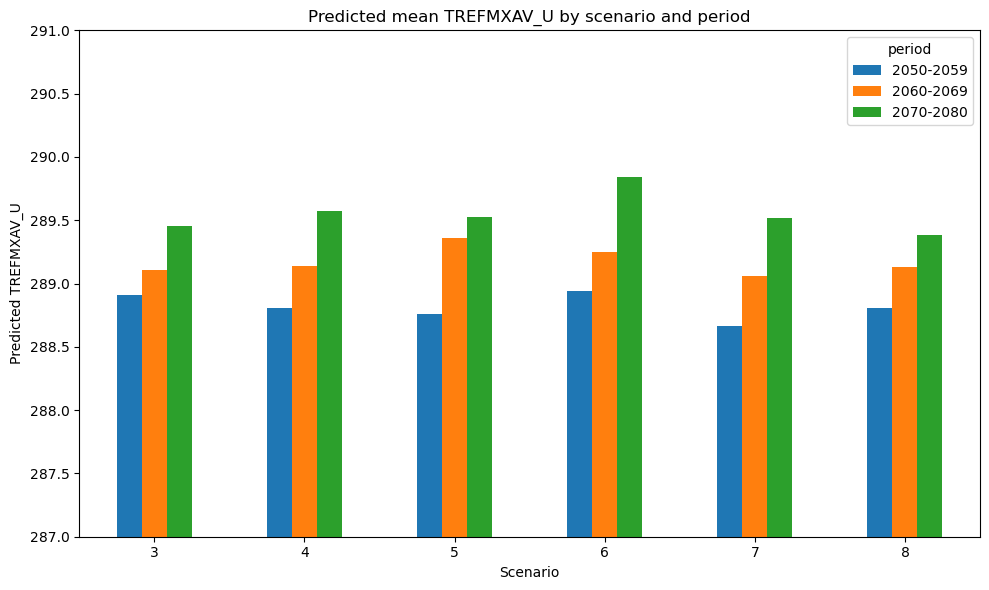

In [22]:
period_pivot = period_summary.pivot(index="scenario", columns="period", values="pred_TREFMXAV_U")

ax = period_pivot.plot(kind="bar", figsize=(10, 6))
ax.set_title("Predicted mean TREFMXAV_U by scenario and period")
ax.set_xlabel("Scenario")
ax.set_ylabel("Predicted TREFMXAV_U")
ax.set_ylim(287,291)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mean_predicted_TREFMXAV_U_by_scenario_and_period.png", dpi=300, bbox_inches="tight")
plt.show()

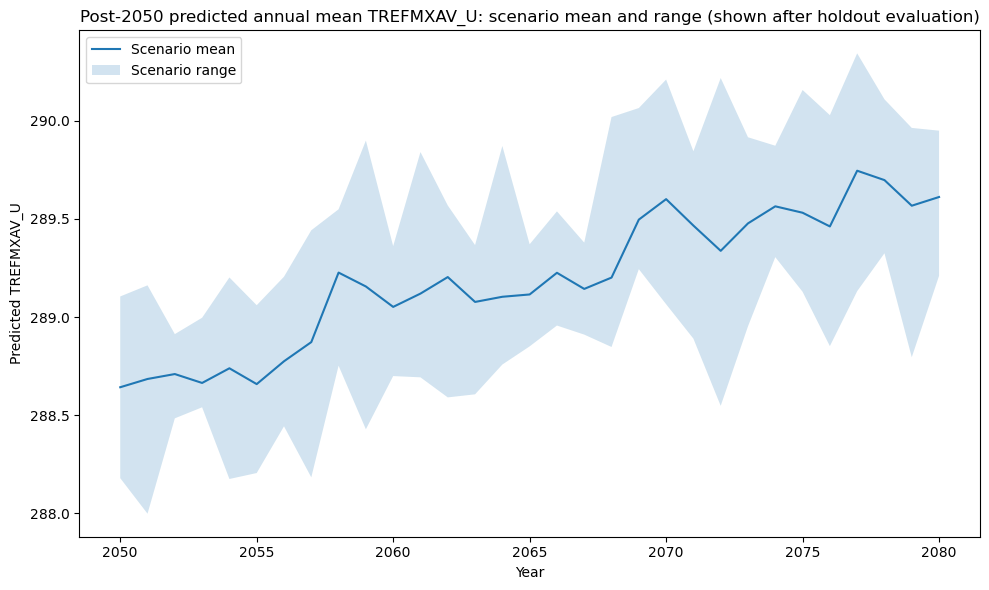

In [23]:
# Overall model behaviour across scenarios with spread

ensemble_summary = (
    annual_preds
    .groupby("year")["pred_TREFMXAV_U"]
    .agg(["mean", "min", "max"])
    .reset_index()
)

plt.figure(figsize=(10, 6))
plt.plot(ensemble_summary["year"], ensemble_summary["mean"], label="Scenario mean")
plt.fill_between(
    ensemble_summary["year"],
    ensemble_summary["min"],
    ensemble_summary["max"],
    alpha=0.2,
    label="Scenario range"
)

plt.title("Post-2050 predicted annual mean TREFMXAV_U: scenario mean and range (shown after holdout evaluation)")
plt.xlabel("Year")
plt.ylabel("Predicted TREFMXAV_U")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "post2050_annual_mean_predictions_scenario_mean_and_range.png", dpi=300, bbox_inches="tight")
plt.show()

## Spatial holdout error across the full grid

Before focusing on scenario-specific warming patterns, inspect where prediction error is largest across grid cells

In [26]:
spatial_error = (
    post2050_plot
    .groupby(["lat", "lon_plot"], as_index=False)[["error", "abs_error", "squared_error"]]
    .mean()
)

spatial_error["rmse"] = np.sqrt(spatial_error["squared_error"])

spatial_error.head()

,lat,lon_plot,error,abs_error,squared_error,rmse
0,49.476440,-1.25,-0.126840,0.419459,0.429400,0.655286
1,50.418850,-5.00,-0.032351,0.281227,0.171099,0.413641
2,50.418850,-3.75,-0.091177,0.332303,0.291093,0.539531
3,50.418850,-2.50,-0.023570,0.340199,0.285185,0.534027
4,51.361256,-3.75,-0.198291,0.351427,0.270230,0.519836


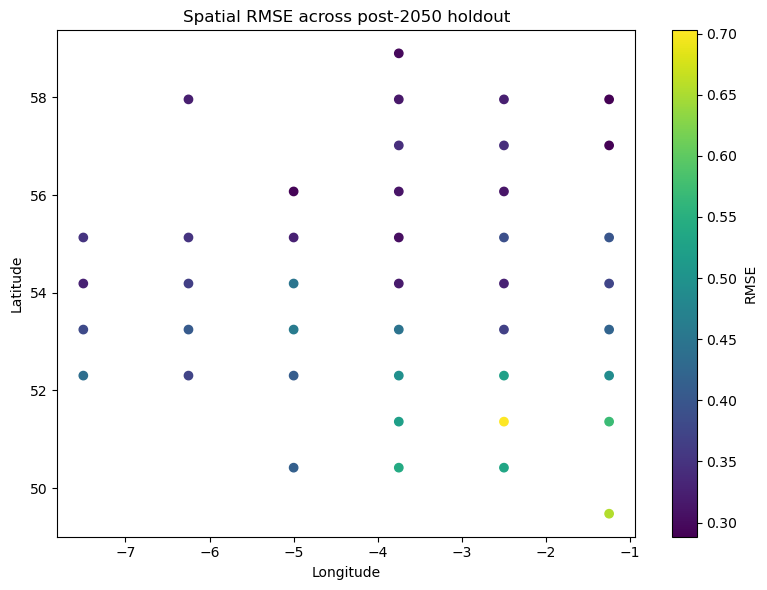

In [27]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(
    spatial_error["lon_plot"],
    spatial_error["lat"],
    c=spatial_error["rmse"]
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial RMSE across post-2050 holdout")
plt.colorbar(sc, label="RMSE")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "post2050_spatial_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

## Spatial analysis for scenario 6

After evaluating overall holdout accuracy, inspect the spatial structure of predicted post-2050 warming for scenario 6. These maps show predicted pattern, not prediction error

In [28]:
scenario6 = post2050_plot[post2050_plot["scenario"].astype(str).isin(["006", "6"])].copy()
print(scenario6.shape)
scenario6.head()

(15624, 33)


,scenario,time,TREFMXAV_U_true,TREFHT,FLNS,FSNS,PRECT,PRSN,QBOT,UBOT,...,QBOT_lag1,wind_speed_lag1,pred_TREFMXAV_U,season,decade,error,abs_error,squared_error,lon_plot,period
46872,6,2050-01-01 00:00:00,285.53470,283.84170,44.058647,33.308628,1.591901e-06,1.824040e-13,0.006062,7.021216,...,0.006067,6.902925,285.51648,DJF,2050,-0.018219,0.018219,0.000332,-1.25,2050-2059
46873,6,2050-02-01 00:00:00,282.72670,280.64264,57.018420,71.898460,9.803708e-07,3.718018e-12,0.004716,1.869963,...,0.006062,8.467361,283.23932,DJF,2050,0.512604,0.512604,0.262763,-1.25,2050-2059
46874,6,2050-03-01 00:00:00,286.82520,283.53940,51.943638,117.303660,5.706308e-07,9.790163e-15,0.005862,5.215613,...,0.004716,2.334276,287.10443,MAM,2050,0.279236,0.279236,0.077973,-1.25,2050-2059
46875,6,2050-04-01 00:00:00,294.49475,287.33954,67.205765,197.972400,1.408097e-07,1.266116e-16,0.006647,-1.043553,...,0.005862,6.462408,292.99400,MAM,2050,-1.500763,1.500763,2.252289,-1.25,2050-2059
46876,6,2050-05-01 00:00:00,294.19012,289.03436,68.928894,238.129320,4.370051e-07,1.592007e-12,0.007619,1.693236,...,0.006647,1.044304,293.85440,MAM,2050,-0.335724,0.335724,0.112711,-1.25,2050-2059


In [29]:
scenario6["period"].value_counts(dropna=False).sort_index()

period
2050-2059    5040
2060-2069    5040
2070-2080    5544
Name: count, dtype: int64

In [30]:
# Aggregate to spatial mean by period

spatial_period = (
    scenario6
    .dropna(subset=["period"])
    .groupby(["period", "lat", "lon_plot"])["pred_TREFMXAV_U"]
    .mean()
    .reset_index()
)

spatial_period.head()

,period,lat,lon_plot,pred_TREFMXAV_U
0,2050-2059,49.476440,-1.25,291.299100
1,2050-2059,50.418850,-5.00,290.176994
2,2050-2059,50.418850,-3.75,290.564240
3,2050-2059,50.418850,-2.50,290.354851
4,2050-2059,51.361256,-3.75,290.126829


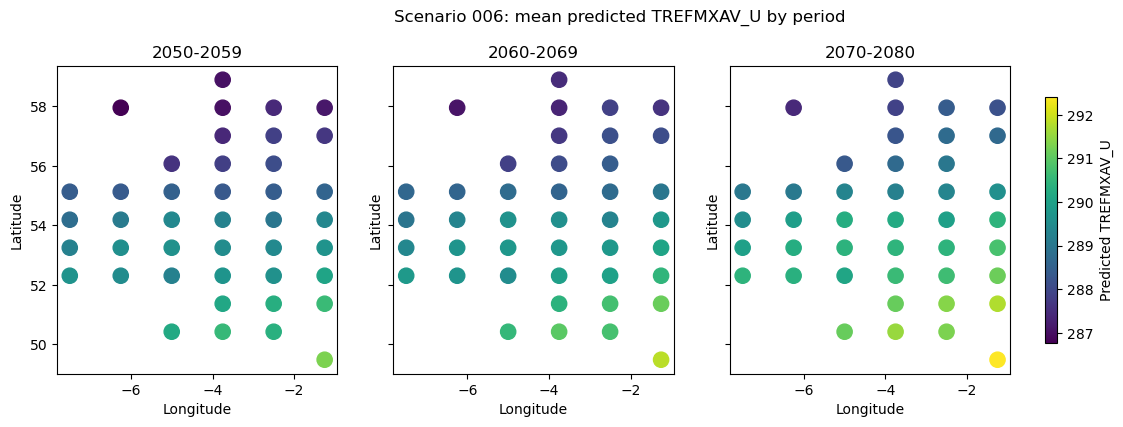

In [31]:
periods = ["2050-2059", "2060-2069", "2070-2080"]

vmin = spatial_period["pred_TREFMXAV_U"].min()
vmax = spatial_period["pred_TREFMXAV_U"].max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, period in zip(axes, periods):
    dfp = spatial_period[spatial_period["period"]==period]

    sc = ax.scatter(
        dfp["lon_plot"],
        dfp["lat"],
        c=dfp["pred_TREFMXAV_U"],
        s=120,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(period)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.colorbar(sc, ax=axes, label="Predicted TREFMXAV_U", shrink=0.8, pad=0.03)

fig.suptitle("Scenario 006: mean predicted TREFMXAV_U by period", y=1.02)
plt.show()

In [32]:
# Plot on a gridded field for a nicer plot

period_grids = {}

for period in periods:
    dfp = spatial_period[spatial_period["period"] == period]
    grid = dfp.pivot(index="lat", columns="lon_plot", values="pred_TREFMXAV_U")
    grid = grid.sort_index().sort_index(axis=1)
    period_grids[period] = grid

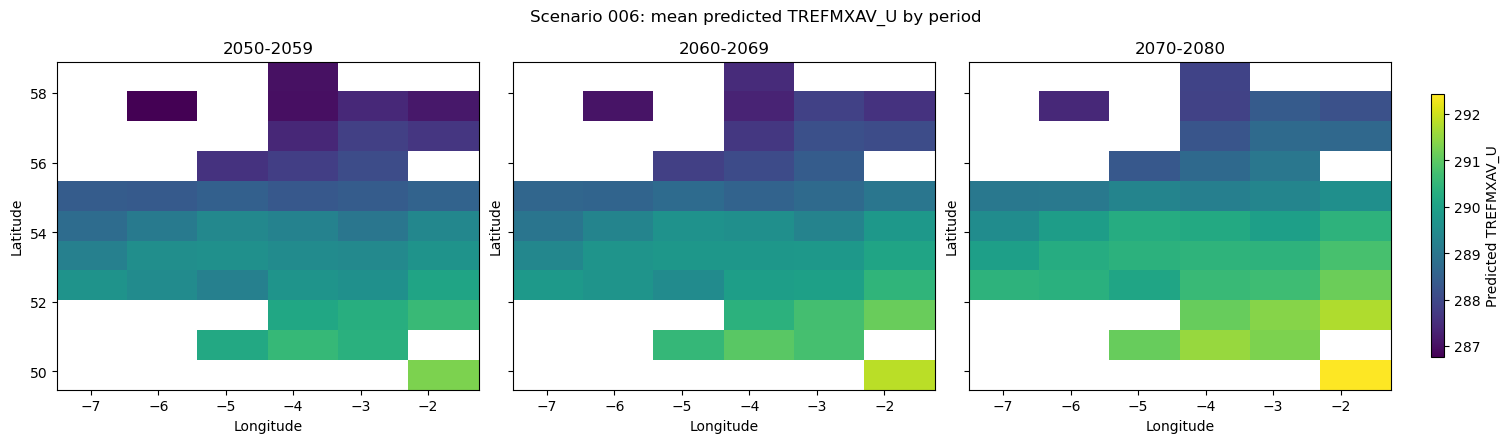

In [33]:
vmin = min(grid.min().min() for grid in period_grids.values())
vmax = max(grid.max().max() for grid in period_grids.values())

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True, constrained_layout=True)

for ax, period in zip(axes, periods):
    grid = period_grids[period]

    im = ax.imshow(
        grid.values,
        origin="lower",
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
        extent=[grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()]
    )

    ax.set_title(period)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.colorbar(im, ax=axes, label="Predicted TREFMXAV_U", shrink=0.8, pad=0.03)

fig.suptitle("Scenario 006: mean predicted TREFMXAV_U by period", y=1.07)
plt.show()

In [34]:
# Change maps relative to 2050 baseline - also correct the lon values

baseline = (
    spatial_period.loc[
        spatial_period["period"] == "2050-2059",
        ["lat", "lon_plot", "pred_TREFMXAV_U"]
    ]
    .rename(columns={"pred_TREFMXAV_U": "baseline_pred"})
)

assert not baseline.empty, "Spatial baseline table is empty. Check period labels in spatial_period."

spatial_change = spatial_period.merge(
    baseline,
    on=["lat", "lon_plot"],
    how="left",
    validate="many_to_one"
)

spatial_change["change_from_2050s"] = (
    spatial_change["pred_TREFMXAV_U"] - spatial_change["baseline_pred"]
)

assert spatial_change["change_from_2050s"].notna().all(), \
    "NaNs detected in spatial_change after baseline merge."

spatial_change.head()

,period,lat,lon_plot,pred_TREFMXAV_U,baseline_pred,change_from_2050s
0,2050-2059,49.476440,-1.25,291.299100,291.299100,0.0
1,2050-2059,50.418850,-5.00,290.176994,290.176994,0.0
2,2050-2059,50.418850,-3.75,290.564240,290.564240,0.0
3,2050-2059,50.418850,-2.50,290.354851,290.354851,0.0
4,2050-2059,51.361256,-3.75,290.126829,290.126829,0.0


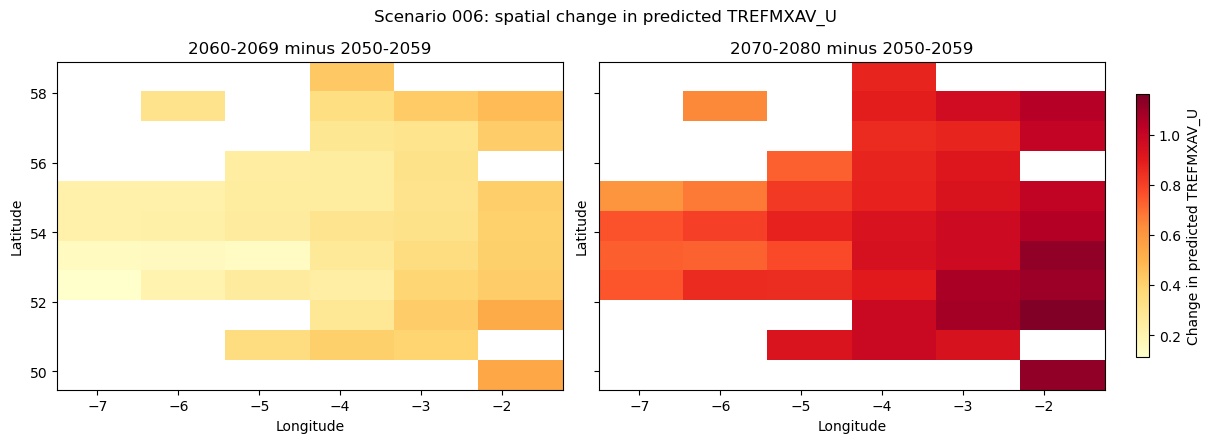

In [35]:
change_periods = ["2060-2069", "2070-2080"]

change_grids = {}

for period in change_periods:
    dfp = spatial_change[spatial_change["period"] == period]
    grid = dfp.pivot(index="lat", columns="lon_plot", values="change_from_2050s")
    grid = grid.sort_index().sort_index(axis=1)
    change_grids[period] = grid

all_change_vals = np.concatenate([grid.values.flatten() for grid in change_grids.values()])
all_change_vals = all_change_vals[~np.isnan(all_change_vals)]

vmin = all_change_vals.min()
vmax = all_change_vals.max()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True, constrained_layout=True)

for ax, period in zip(axes, change_periods):
    grid = change_grids[period]

    im = ax.imshow(
        grid.values,
        origin="lower",
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
        cmap="YlOrRd",
        extent=[grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()]
    )

    ax.set_title(f"{period} minus 2050-2059")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.colorbar(im, ax=axes, label="Change in predicted TREFMXAV_U", shrink=0.8, pad=0.03)

fig.suptitle("Scenario 006: spatial change in predicted TREFMXAV_U", y=1.07)
plt.show()

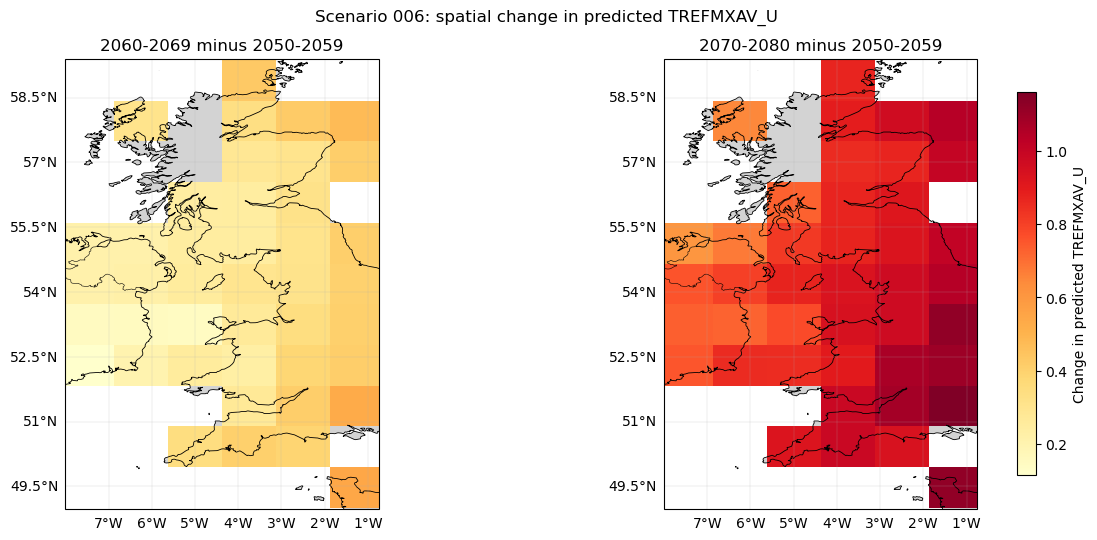

In [36]:
# Cartopy version with background map

change_periods = ["2060-2069", "2070-2080"]
change_grids = {}

for period in change_periods:
    dfp = spatial_change[spatial_change["period"] == period]
    assert not dfp.empty, f"No spatial change data found for period {period}"

    grid = dfp.pivot(index="lat", columns="lon_plot", values="change_from_2050s")
    grid = grid.sort_index().sort_index(axis=1)
    change_grids[period] = grid

# Actual color scale from the data
all_change_vals = np.concatenate([grid.values.flatten() for grid in change_grids.values()])
all_change_vals = all_change_vals[~np.isnan(all_change_vals)]

assert all_change_vals.size > 0, "No finite values found for cartopy spatial change plot."

vmin = all_change_vals.min()
vmax = all_change_vals.max()

# Map extent
all_lons = np.concatenate([grid.columns.values for grid in change_grids.values()])
all_lats = np.concatenate([grid.index.values for grid in change_grids.values()])

lon_min, lon_max = all_lons.min(), all_lons.max()
lat_min, lat_max = all_lats.min(), all_lats.max()

lon_buffer = 0.5
lat_buffer = 0.5

extent = [
    lon_min - lon_buffer,
    lon_max + lon_buffer,
    lat_min - lat_buffer,
    lat_max + lat_buffer,
]

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

for ax, period in zip(axes, change_periods):
    grid = change_grids[period]

    im = ax.pcolormesh(
        grid.columns.values,
        grid.index.values,
        grid.values,
        transform=ccrs.PlateCarree(),
        cmap="YlOrRd",
        vmin=vmin,
        vmax=vmax,
        shading="auto"
    )

    ax.set_extent(extent, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(f"{period} minus 2050-2059")

cbar = fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.85, pad=0.03)
cbar.set_label("Change in predicted TREFMXAV_U")

fig.suptitle("Scenario 006: spatial change in predicted TREFMXAV_U", y=1.05, x=0.58)
fig.savefig(
    FIGURES_DIR / "scenario006_spatial_change_cartopy.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Seasonal change section

Having checked overall and grouped holdout performance, compare predicted seasonal warming across post-2050 periods relative to the 2050-2059 baseline

In [37]:
monthly_period_summary = (
    post2050
    .groupby(["period", "month"], observed=True)["pred_TREFMXAV_U"]
    .mean()
    .reset_index()
)

actual_periods = set(monthly_period_summary["period"].dropna().astype(str).unique())
assert actual_periods == set(period_labels), f"Unexpected period labels in monthly_period_summary: {sorted(actual_periods)}"

baseline_2050s = (
    monthly_period_summary.loc[
        monthly_period_summary["period"] == "2050-2059",
        ["month", "pred_TREFMXAV_U"]
    ]
    .rename(columns={"pred_TREFMXAV_U": "baseline_2050s"})
)

assert not baseline_2050s.empty, "Baseline monthly table is empty."
assert baseline_2050s["month"].nunique() == 12, "Baseline monthly table does not contain all 12 months."

monthly_change = monthly_period_summary.merge(
    baseline_2050s,
    on="month",
    how="left",
    validate="many_to_one"
)

monthly_change["change_from_2050s"] = (
    monthly_change["pred_TREFMXAV_U"] - monthly_change["baseline_2050s"]
)

assert monthly_change["change_from_2050s"].notna().all(), "NaNs detected in monthly_change after baseline merge."

monthly_change

,period,month,pred_TREFMXAV_U,baseline_2050s,change_from_2050s
0,2050-2059,1,283.689960,283.689960,0.000000
1,2050-2059,2,283.784009,283.784009,0.000000
2,2050-2059,3,284.973071,284.973071,0.000000
3,2050-2059,4,287.337252,287.337252,0.000000
4,2050-2059,5,290.528647,290.528647,0.000000
5,2050-2059,6,293.383960,293.383960,0.000000
6,2050-2059,7,295.018295,295.018295,0.000000
7,2050-2059,8,294.851577,294.851577,0.000000
8,2050-2059,9,292.556768,292.556768,0.000000
9,2050-2059,10,289.244841,289.244841,0.000000


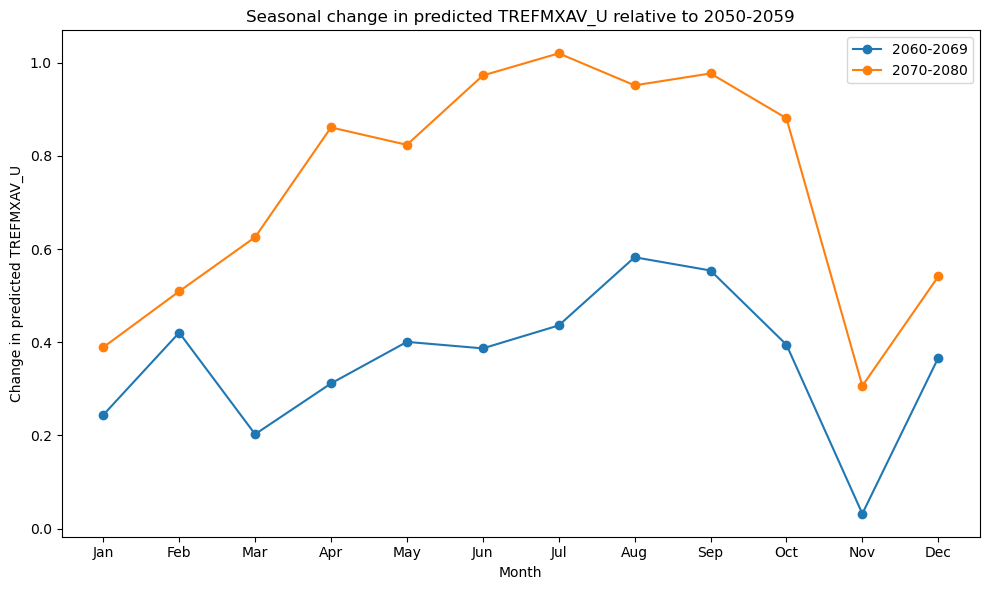

In [38]:
month_labels = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

change_plot_df = monthly_change[
    monthly_change["period"].isin(["2060-2069", "2070-2080"])
].copy()

assert not change_plot_df.empty, "No rows available for seasonal change plot."

change_plot_df["month_name"] = change_plot_df["month"].map(month_labels)

plt.figure(figsize=(10, 6))

for period, grp in change_plot_df.groupby("period", observed=True):
    plt.plot(grp["month_name"], grp["change_from_2050s"], marker="o", label=period)

plt.title("Seasonal change in predicted TREFMXAV_U relative to 2050-2059")
plt.xlabel("Month")
plt.ylabel("Change in predicted TREFMXAV_U")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "post2050_seasonal_change_relative_to_2050_2059.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
monthly_change.to_csv(TABLES_DIR / "post2050_predicted_monthly_change_relative_to_2050_2059.csv", index=False)

### Manchester vs wider grid comparison

Compare the Manchester grid cell against the wider study region, while treating these results as pattern interpretation rather than direct evidence of model accuracy

### Manchester holdout evaluation  


In [41]:
manchester_lat = 53.48
manchester_lon = -2.24

# Find nearest available grid point in the post-2050 holdout table
grid_points = (
    post2050_plot[["lat", "lon_plot"]]
    .drop_duplicates()
    .copy()
)

grid_points["dist2"] = (
    (grid_points["lat"] - manchester_lat) ** 2
    + (grid_points["lon_plot"] - manchester_lon) ** 2
)

nearest_point = grid_points.loc[grid_points["dist2"].idxmin()]

nearest_lat = nearest_point["lat"]
nearest_lon = nearest_point["lon_plot"]

print("Nearest grid point to Manchester:")
print("lat =", nearest_lat, "lon =", nearest_lon)

manchester_mask = (
    (post2050_plot["lat"] == nearest_lat) &
    (post2050_plot["lon_plot"] == nearest_lon)
)

manchester_eval = post2050_plot[manchester_mask].copy()

regression_metrics(
    manchester_eval["TREFMXAV_U_true"],
    manchester_eval["pred_TREFMXAV_U"]
)

Nearest grid point to Manchester:
lat = 53.246075 lon = -2.5


{'rmse': 0.368721295318768,
 'mae': 0.2682387141577059,
 'r2': 0.9941365018881078,
 'bias': -0.06259725358422946}

In [42]:
# Find Manchester grid cell

manchester_lat = 53.48
manchester_lon = -2.24

grid_cells = post2050_plot[["lat", "lon", "lon_plot"]].drop_duplicates().copy()

grid_cells["distance_sq"] = (
    (grid_cells["lat"] - manchester_lat) ** 2 +
    (grid_cells["lon_plot"] - manchester_lon) ** 2
)

manchester_cell = grid_cells.sort_values("distance_sq").iloc[0]
manchester_cell

lat             53.246075
lon            357.500000
lon_plot        -2.500000
distance_sq      0.122321
Name: 6324, dtype: float64

In [43]:
# Subset Manchester predictions

manchester_preds = post2050_plot[
    (post2050_plot["lat"] == manchester_cell["lat"]) &
    (post2050_plot["lon"] == manchester_cell["lon"])
].copy()

manchester_preds = add_period_column(manchester_preds)

manchester_preds.head()

,scenario,time,TREFMXAV_U_true,TREFHT,FLNS,FSNS,PRECT,PRSN,QBOT,UBOT,...,QBOT_lag1,wind_speed_lag1,pred_TREFMXAV_U,season,decade,error,abs_error,squared_error,lon_plot,period
6324,3,2050-01-01 00:00:00,283.27610,279.71887,35.651497,22.07937,2.315912e-06,6.554333e-10,0.005105,1.601060,...,0.005224,3.235479,283.33902,DJF,2050,0.062927,0.062927,0.003960,-2.5,2050-2059
6325,3,2050-02-01 00:00:00,283.21982,279.34225,41.690090,50.14652,1.103255e-06,6.384433e-13,0.004648,-1.966219,...,0.005105,3.616130,283.24353,DJF,2050,0.023712,0.023712,0.000562,-2.5,2050-2059
6326,3,2050-03-01 00:00:00,283.27432,279.29970,46.564575,82.98831,1.104698e-06,3.485447e-09,0.004290,-0.084587,...,0.004648,2.279030,283.36820,MAM,2050,0.093872,0.093872,0.008812,-2.5,2050-2059
6327,3,2050-04-01 00:00:00,288.82034,283.29407,63.524654,156.58124,7.541164e-07,1.664246e-12,0.004695,1.800647,...,0.004290,0.767310,288.89190,MAM,2050,0.071564,0.071564,0.005121,-2.5,2050-2059
6328,3,2050-05-01 00:00:00,293.23364,288.31296,56.167892,180.35382,2.878063e-07,6.153016e-17,0.006683,-2.002363,...,0.004695,1.928236,293.63208,MAM,2050,0.398438,0.398438,0.158752,-2.5,2050-2059


In [44]:
# Compare period means

regional_period = (
    post2050
    .groupby("period", observed=True)["pred_TREFMXAV_U"]
    .mean()
    .reset_index()
    .rename(columns={"pred_TREFMXAV_U": "regional_mean"})
)

manchester_period = (
    manchester_preds
    .groupby("period", observed=True)["pred_TREFMXAV_U"]
    .mean()
    .reset_index()
    .rename(columns={"pred_TREFMXAV_U": "manchester_mean"})
)

assert not regional_period.empty, "Regional period summary is empty."
assert not manchester_period.empty, "Manchester period summary is empty."

manchester_vs_region_period = regional_period.merge(
    manchester_period,
    on="period",
    how="left",
    validate="one_to_one"
)

assert manchester_vs_region_period[["regional_mean", "manchester_mean"]].notna().all().all(), \
    "NaNs detected in Manchester vs region period summary."

manchester_vs_region_period

,period,regional_mean,manchester_mean
0,2050-2059,288.812967,289.413781
1,2060-2069,289.173870,289.716231
2,2070-2080,289.551139,290.144370


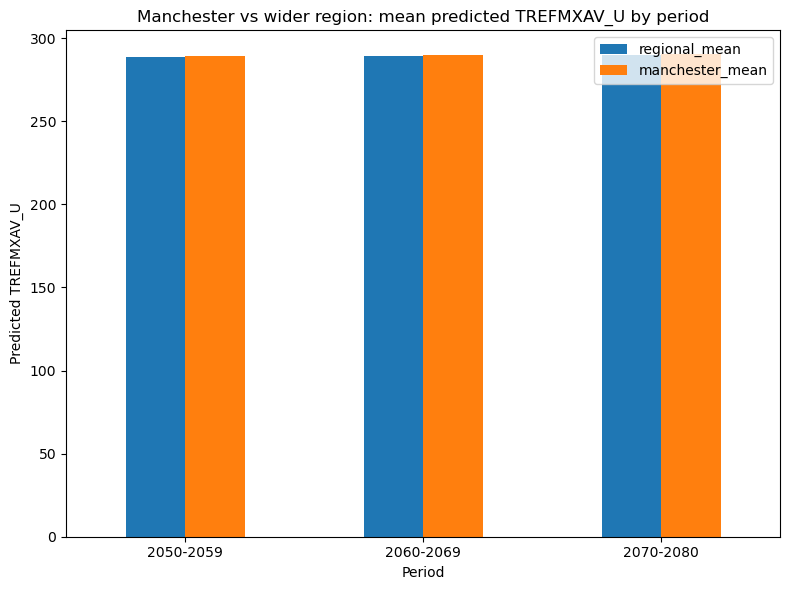

In [45]:
# Plot period comparison

plot_df = manchester_vs_region_period.set_index("period")

ax = plot_df.plot(kind="bar", figsize=(8, 6))
ax.set_title("Manchester vs wider region: mean predicted TREFMXAV_U by period")
ax.set_xlabel("Period")
ax.set_ylabel("Predicted TREFMXAV_U")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [46]:
manchester_vs_region_period.to_csv(TABLES_DIR / "manchester_vs_region_preds_period_summary.csv", index=False)

### Manchester seasonal comparison  


In [47]:
regional_month = (
    post2050
    .groupby("month")["pred_TREFMXAV_U"]
    .mean()
    .reset_index()
    .rename(columns={"pred_TREFMXAV_U": "regional_mean"})
)

manchester_month = (
    manchester_preds
    .groupby("month")["pred_TREFMXAV_U"]
    .mean()
    .reset_index()
    .rename(columns={"pred_TREFMXAV_U": "manchester_mean"})
)

manchester_vs_region_month = regional_month.merge(
    manchester_month,
    on="month",
    how="left",
    validate="one_to_one"
)

assert manchester_vs_region_month[["regional_mean", "manchester_mean"]].notna().all().all(), \
    "NaNs detected in Manchester vs region monthly summary."

manchester_vs_region_month["month_name"] = manchester_vs_region_month["month"].map(month_labels)

manchester_vs_region_month

,month,regional_mean,manchester_mean,month_name
0,1,283.906691,283.955393,Jan
1,2,284.100350,284.277627,Feb
2,3,285.260320,285.723864,Mar
3,4,287.743286,288.686512,Apr
4,5,290.950208,292.080758,May
5,6,293.853843,295.130620,Jun
6,7,295.520930,296.746412,Jul
7,8,295.377063,296.287707,Aug
8,9,293.082141,293.528163,Sep
9,10,289.684674,289.946401,Oct


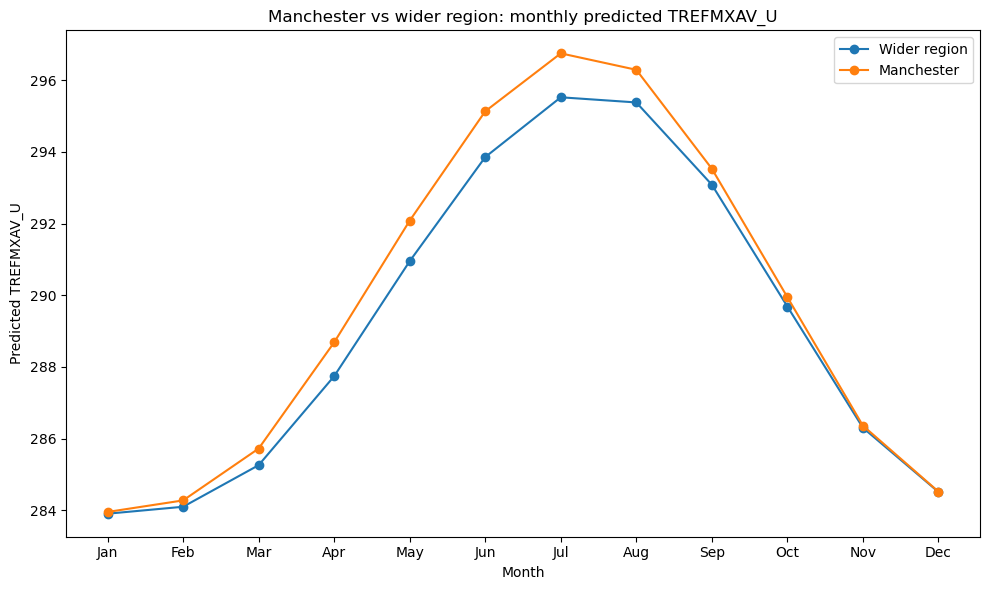

In [48]:
plt.figure(figsize=(10, 6))
plt.plot(manchester_vs_region_month["month_name"], manchester_vs_region_month["regional_mean"], marker="o", label="Wider region")
plt.plot(manchester_vs_region_month["month_name"], manchester_vs_region_month["manchester_mean"], marker="o", label="Manchester")

plt.title("Manchester vs wider region: monthly predicted TREFMXAV_U")
plt.xlabel("Month")
plt.ylabel("Predicted TREFMXAV_U")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "manchester_vs_region_monthly_predicted_trefmxav_u.png", dpi=300, bbox_inches="tight")
plt.show()

In [49]:
manchester_vs_region_month.to_csv(TABLES_DIR / "manchester_vs_region_preds_monthly_summary.csv", index=False)

### Manchester vs full region warming relative to baseline:  



In [50]:
manchester_monthly_period = (
    manchester_preds
    .groupby(["period", "month"], observed=True)["pred_TREFMXAV_U"]
    .mean()
    .reset_index()
)

baseline_manchester = (
    manchester_monthly_period.loc[
        manchester_monthly_period["period"] == "2050-2059",
        ["month", "pred_TREFMXAV_U"]
    ]
    .rename(columns={"pred_TREFMXAV_U": "baseline_2050s_manchester"})
)

assert not baseline_manchester.empty, "Manchester baseline table is empty."
assert baseline_manchester["month"].nunique() == 12, "Manchester baseline table does not contain all 12 months."

manchester_monthly_change = manchester_monthly_period.merge(
    baseline_manchester,
    on="month",
    how="left",
    validate="many_to_one"
)

manchester_monthly_change["change_from_2050s"] = (
    manchester_monthly_change["pred_TREFMXAV_U"] - manchester_monthly_change["baseline_2050s_manchester"]
)

assert manchester_monthly_change["change_from_2050s"].notna().all(), \
    "NaNs detected in Manchester monthly change."

regional_2070 = monthly_change.loc[
    monthly_change["period"] == "2070-2080",
    ["month", "change_from_2050s"]
].rename(columns={"change_from_2050s": "regional_change"})

manchester_2070 = manchester_monthly_change.loc[
    manchester_monthly_change["period"] == "2070-2080",
    ["month", "change_from_2050s"]
].rename(columns={"change_from_2050s": "manchester_change"})

compare_2070 = regional_2070.merge(
    manchester_2070,
    on="month",
    how="left",
    validate="one_to_one"
)

assert compare_2070[["regional_change", "manchester_change"]].notna().all().all(), \
    "NaNs detected in compare_2070."

compare_2070["month_name"] = compare_2070["month"].map(month_labels)

compare_2070

,month,regional_change,manchester_change,month_name
0,1,0.389108,0.353265,Jan
1,2,0.509206,0.463004,Feb
2,3,0.625457,0.629690,Mar
3,4,0.861129,0.909321,Apr
4,5,0.823753,0.920399,May
5,6,0.972647,1.185983,Jun
6,7,1.020153,0.949496,Jul
7,8,0.951484,0.891872,Aug
8,9,0.977025,0.924298,Sep
9,10,0.880800,0.797683,Oct


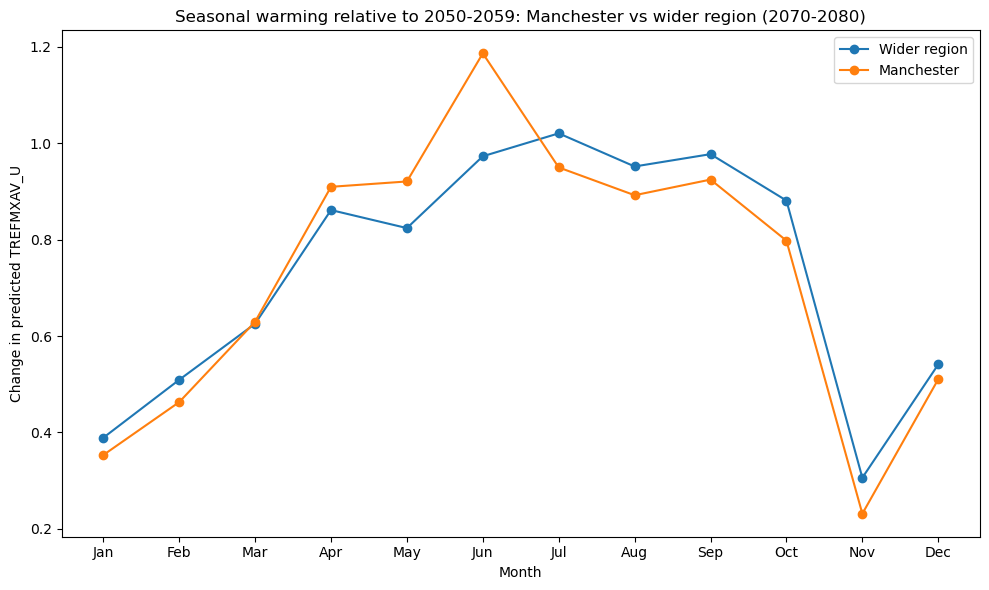

In [51]:
plt.figure(figsize=(10, 6))
plt.plot(compare_2070["month_name"], compare_2070["regional_change"], marker="o", label="Wider region")
plt.plot(compare_2070["month_name"], compare_2070["manchester_change"], marker="o", label="Manchester")

plt.title("Seasonal warming relative to 2050-2059: Manchester vs wider region (2070-2080)")
plt.xlabel("Month")
plt.ylabel("Change in predicted TREFMXAV_U")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "manchester_vs_region_preds_seasonal_warming_2070_2080.png", dpi=300, bbox_inches="tight")
plt.show()

In [52]:
compare_2070.to_csv(TABLES_DIR / "manchester_vs_region_preds_2070_2080_monthly_change.csv", index=False)

## Summary

This notebook includes **holdout evaluation** of post-2050 predictions against the true post-2050 `TREFMXAV_U` values available in the dataset. The sections above on overall metrics, grouped metrics, residuals, and local/spatial checks should be used to judge how reliable the later interpretation is.

The points below summarise **predicted** post-2050 patterns in `TREFMXAV_U`, rather than the true post-2050 values themselves. They should therefore be interpreted alongside the earlier holdout evaluation results, which show how well the model reproduces true post-2050 `TREFMXAV_U`.

#### Overall pattern across scenarios
- All scenarios show an increase in predicted `TREFMXAV_U` after 2050, with mean values in the 2070-2080 period higher than in 2050-2059.
- Scenario differences exist, but they are modest.
- Among the scenarios, scenario 6 shows the highest late-period mean (**289.84**), while scenario 3 and scenario 8 are lower (**289.45** and **289.39** respectively).
- This suggests variation in predicted warming magnitude across scenarios, but not a complete separation of trajectories.

#### Seasonal variation in warming
- Predicted warming is not uniform through the year.
- Compared to the 2050-2059 baseline, warming in 2060-2069 is already positive in almost every month, but is relatively small in **November (+0.03)**.
- By 2070-2080, predicted warming is strongest in the warmer part of the year:
    - **July (+1.02)**
    - **September (+0.98)**
    - **June (+0.97)**
    - **August (+0.95)**
- Weakest late-period warming occurs in **November (+0.31)** and **January (+0.39)**.
- This indicates a clear **predicted** seasonal amplification, with increases stronger in late spring, summer, and early autumn than in late autumn and winter.

#### Manchester vs wider study region
- The Manchester grid point is consistently warmer than the full study-region average in all post-2050 periods:
    - **2050-2059:** Manchester **289.41** vs region **288.81**
    - **2060-2069:** Manchester **289.72** vs region **289.17**
    - **2070-2080:** Manchester **290.14** vs region **289.55**
- This suggests Manchester follows the same broad predicted warming trend as the wider region, but at a slightly higher absolute temperature level.
- This Manchester-specific interpretation should be read together with the local holdout evaluation shown earlier.

#### Manchester seasonal pattern
- The predicted seasonal cycle for Manchester is very similar to that of the full study region.
- However, Manchester is generally warmer in most months, with the largest differences in late spring and summer:
    - **May:** Manchester **292.08** vs region **290.95**
    - **June:** Manchester **295.13** vs region **293.85**
    - **July:** Manchester **296.75** vs region **295.52**
- This suggests that Manchester broadly follows the same seasonal pattern, but with stronger warm-season intensity in the predictions.

#### Manchester warming relative to baseline
- Predicted warming relative to the 2050-2059 baseline is broadly consistent with the wider region, but not identical.
- In 2070-2080, Manchester shows:
    - greater warming than the full region in **April, May, and June**, especially **June (+1.19 vs +0.97)**
    - slightly lower warming than the wider region in **January, February, July, August, September, October, November, and December**
- This suggests Manchester does not simply mirror the full-region mean, but instead shows a similar overall trend with some seasonal differences in predicted warming magnitude.

#### Spatial interpretation
- Spatial maps for scenario 6 indicate that predicted warming is positive across the valid grid points, but the magnitude of change is not identical everywhere.
- Because `TREFMXAV_U` is only available for a subset of cells, these maps should be interpreted as warming patterns over the valid target grid rather than a complete picture across the whole UK map.
- These predicted spatial patterns should also be considered alongside the earlier spatial holdout error diagnostics.

#### Overall interpretation
- Taken together, the notebook supports two linked conclusions:
    1. the model produces interpretable post-2050 spatial, seasonal, and scenario-dependent prediction patterns; and
    2. those patterns should be judged in the context of the holdout evaluation against true post-2050 `TREFMXAV_U` values, rather than treated as unchecked projection summaries.